In [ ]:
import requests
import pandas as pd
import time

API_KEY = "RGAPI-02710b7f-7a52-4193-95d9-b0c83a042fdd"
COUNT = 250

ACCOUNTS = [
    {"name": "StârMuhtar",       "summoner": "StârMuhtar",       "tag": "TR1",   "rank": "Emerald",     "group": "mine"},
    {"name": "FrozênMuhtar",     "summoner": "FrozênMuhtar",     "tag": "TR1",   "rank": "Master",      "group": "mine"},
    {"name": "freak999",         "summoner": "freak999",         "tag": "999",   "rank": "Emerald",     "group": "mine"},
    {"name": "JPL",              "summoner": "JPL",              "tag": "00000", "rank": "Platinum",    "group": "mine"},
    {"name": "JPL",              "summoner": "JPL",              "tag": "00001", "rank": "Diamond",     "group": "mine"},
    {"name": "JPL",              "summoner": "JPL",              "tag": "00002", "rank": "Platinum",    "group": "mine"},
    {"name": "Kocanım",          "summoner": "Kocanım",          "tag": "JPL",   "rank": "Diamond",     "group": "friends"},
    {"name": "G0DMEN",           "summoner": "G0DMEN",           "tag": "832",   "rank": "Iron",        "group": "friends"},
    {"name": "İGOR4554",         "summoner": "İGOR4554",         "tag": "5000",  "rank": "Bronze",      "group": "friends"},
    {"name": "volibear444",      "summoner": "volibear444",      "tag": "TR1",   "rank": "Silver",      "group": "friends"},
    {"name": "Ricci Rocco",      "summoner": "Ricci Rocco",      "tag": "TR1",   "rank": "Gold",        "group": "friends"},
    {"name": "u88",              "summoner": "u88",              "tag": "TR1",   "rank": "GrandMaster", "group": "friends"},
    {"name": "turkish taliyah",  "summoner": "turkish taliyah",  "tag": "kick",  "rank": "Challenger",  "group": "friends"},
    {"name": "Sihirdar Olacam",  "summoner": "Sihirdar Olacam",  "tag": "Sihir", "rank": "Platinum",    "group": "friends"},
    {"name": "S A V A G E",      "summoner": "S A V A G E",      "tag": "389",   "rank": "Platinum",    "group": "friends"},
    {"name": "KAZUMASAN2",       "summoner": "KAZUMASAN2",       "tag": "TR1",   "rank": "Iron",        "group": "friends"},
    {"name": "ExpertMurderer",   "summoner": "ExpertMurderer",   "tag": "9651",  "rank": "Bronze",      "group": "friends"},
    {"name": "ÇAYCIGOSU",        "summoner": "ÇAYCIGOSU",        "tag": "TEA",   "rank": "Silver",      "group": "friends"},
    {"name": "flame enjoyer",    "summoner": "flame enjoyer",    "tag": "emo",   "rank": "Gold",        "group": "friends"},
    {"name": "Xirtheasy",        "summoner": "Xirtheasy",        "tag": "TR1",   "rank": "Platinum",    "group": "friends"},
    {"name": "Ekremcantunca",    "summoner": "Ekremcantunca",    "tag": "0016",  "rank": "Emerald",     "group": "friends"},
    {"name": "herr müller",      "summoner": "herr müller",      "tag": "DE1",   "rank": "Diamond",     "group": "friends"},
    {"name": "Eobard Thawne RF", "summoner": "Eobard Thawne RF", "tag": "017",   "rank": "Master",      "group": "friends"},
    {"name": "outmind",          "summoner": "outmind",          "tag": "TR1",   "rank": "GrandMaster", "group": "friends"},
    {"name": "broski mroski",    "summoner": "broski mroski",    "tag": "3107",  "rank": "Challenger",  "group": "friends"},
]

# ─── YARDIMCI FONKSİYONLAR ───────────────────────────────────────────────────

def safe_get(url, retries=5):
    """Rate limit ve geçici hatalarda otomatik tekrar dener."""
    for i in range(retries):
        r = requests.get(url)
        if r.status_code == 429:
            wait = int(r.headers.get('Retry-After', 15))
            print(f"  Rate limit! {wait}s bekleniyor...")
            time.sleep(wait)
            continue
        if r.status_code != 200:
            raise Exception(f"HTTP {r.status_code}: {r.text}")
        return r
    raise Exception("Max retry aşıldı")

def get_puuid(summoner, tag):
    url = (
        f"https://europe.api.riotgames.com/riot/account/v1/accounts/by-riot-id/"
        f"{summoner}/{tag}?api_key={API_KEY}"
    )
    return safe_get(url).json()['puuid']

def fetch_match_ids(puuid, total_count):
    """100'er 100'er istek atarak toplam total_count kadar match ID toplar."""
    all_ids = []
    batch   = 100
    start   = 0

    while len(all_ids) < total_count:
        kalan = total_count - len(all_ids)
        adet  = min(batch, kalan)
        url   = (
            f"https://europe.api.riotgames.com/lol/match/v5/matches/by-puuid/{puuid}/ids"
            f"?start={start}&count={adet}&queue=420&api_key={API_KEY}"
        )
        resp = safe_get(url).json()

        if not isinstance(resp, list):
            print(f"  Match listesi hatası: {resp}")
            break
        if len(resp) == 0:
            break  # daha fazla maç yok

        all_ids.extend(resp)
        start += adet
        time.sleep(1.3)

        if len(resp) < adet:
            break  # hesapta yeterli maç kalmadı

    return all_ids[:total_count]

def fetch_match_data(puuid, total_count, player_name, rank):
    match_ids = fetch_match_ids(puuid, total_count)
    print(f"[{player_name}] {len(match_ids)} maç işleniyor...")

    data_list = []
    for m_id in match_ids:
        try:
            time.sleep(1.3)
            res  = safe_get(
                f"https://europe.api.riotgames.com/lol/match/v5/matches/{m_id}?api_key={API_KEY}"
            ).json()

            info    = res['info']
            p_stats = next(p for p in info['participants'] if p['puuid'] == puuid)
            team_id = p_stats['teamId']
            team_stats = next(t for t in info['teams'] if t['teamId'] == team_id)
            opp_stats  = next(t for t in info['teams'] if t['teamId'] != team_id)

            obj = team_stats['objectives']
            opp = opp_stats['objectives']

            raw        = info['gameVersion'].split('.')
            patch_str  = f"{raw[0]}.{raw[1].zfill(2)}"

            data_list.append({
                'match_id':         m_id,
                'patch':            patch_str,
                'player':           player_name,
                'rank':             rank,
                'champion':         p_stats['championName'],
                'role':             p_stats.get('teamPosition', 'UNKNOWN'),
                'win':              1 if p_stats['win'] else 0,
                'duration_min':     info['gameDuration'] / 60,
                # Objectives
                'first_tower':      1 if obj['tower']['first']                       else 0,
                'first_dragon':     1 if obj['dragon']['first']                      else 0,
                'first_baron':      1 if obj['baron']['first']                       else 0,
                'first_riftherald': 1 if obj.get('riftHerald', {}).get('first', False) else 0,
                'dragon_kills':     obj['dragon']['kills'],
                'baron_kills':      obj['baron']['kills'],
                'tower_kills':      obj['tower']['kills'],
                'inhibitor_kills':  obj['inhibitor']['kills'],
                # Göreli üstünlük
                'dragon_adv':       obj['dragon']['kills'] - opp['dragon']['kills'],
                'baron_adv':        obj['baron']['kills']  - opp['baron']['kills'],
                'tower_adv':        obj['tower']['kills']  - opp['tower']['kills'],
                # Oyuncu istatistikleri
                'kills':            p_stats['kills'],
                'deaths':           p_stats['deaths'],
                'assists':          p_stats['assists'],
                'kda':              (p_stats['kills'] + p_stats['assists']) / max(p_stats['deaths'], 1),
                'damage':           p_stats['totalDamageDealtToChampions'],
                'gold':             p_stats['goldEarned'],
                'cs':               p_stats['totalMinionsKilled'] + p_stats.get('neutralMinionsKilled', 0),
                'vision_score':     p_stats.get('visionScore', 0),
            })
        except Exception as e:
            print(f"  Atlandı {m_id}: {e}")

    return pd.DataFrame(data_list)

# ─── ANA DÖNGÜ ────────────────────────────────────────────────────────────────

all_dfs = []
for acc in ACCOUNTS:
    try:
        print(f"\n{acc['name']} işleniyor...")
        puuid = get_puuid(acc['summoner'], acc['tag'])
        df    = fetch_match_data(puuid, COUNT, acc['name'], acc['rank'])
        all_dfs.append(df)
        print(f"  -> {len(df)} satır toplandı")
    except Exception as e:
        print(f"  Hata — {acc['name']}: {e}")

if all_dfs:
    final_df = pd.concat(all_dfs, ignore_index=True)
    final_df.to_csv("lol_dataset.csv", index=False)
    print(f"\nTamamlandı! Toplam satır: {len(final_df)}")
    print(final_df.head())
else:
    print("\nHiç veri toplanamadı. API key'ini kontrol et.")


StârMuhtar işleniyor...
[StârMuhtar] 124 maç işleniyor...
  -> 124 satır toplandı

FrozênMuhtar işleniyor...
[FrozênMuhtar] 171 maç işleniyor...
  -> 171 satır toplandı

freak999 işleniyor...
[freak999] 234 maç işleniyor...
  -> 234 satır toplandı

JPL işleniyor...
[JPL] 51 maç işleniyor...
  -> 51 satır toplandı

JPL işleniyor...
[JPL] 157 maç işleniyor...
  -> 157 satır toplandı

JPL işleniyor...
[JPL] 22 maç işleniyor...
  -> 22 satır toplandı

Kocanım işleniyor...
[Kocanım] 250 maç işleniyor...
  -> 250 satır toplandı

G0DMEN işleniyor...
[G0DMEN] 117 maç işleniyor...
  -> 117 satır toplandı

İGOR4554 işleniyor...
[İGOR4554] 250 maç işleniyor...
  -> 250 satır toplandı

volibear444 işleniyor...
[volibear444] 250 maç işleniyor...
  Atlandı TR1_1698998569: 
  -> 249 satır toplandı

Ricci Rocco işleniyor...
[Ricci Rocco] 250 maç işleniyor...
  -> 250 satır toplandı

u88 işleniyor...
[u88] 250 maç işleniyor...
  -> 250 satır toplandı

turkish taliyah işleniyor...
[turkish taliyah] 250

✅ group column OK — mine: 759, friends: 4467 matches

Unmatched 1503 tier combinations
Total: 5253 | Matched: 954 | Rate: 18.2%

############################################################
  RANK: IRON  (219 maç)
############################################################

  WIN RATES — Iron
  first_dragon           Secured: 56.2%  |  Not: 32.3%  |  Fark: +23.9%
  first_baron            Secured: 76.3%  |  Not: 29.4%  |  Fark: +46.9%
  first_tower            Secured: 62.0%  |  Not: 27.6%  |  Fark: +34.4%
  first_riftherald       Secured: 55.2%  |  Not: 36.2%  |  Fark: +19.0%

  Korelasyonlar (win ile):
tower_adv           0.866234
dragon_adv          0.625409
baron_adv           0.518915
first_baron         0.421529
first_tower         0.343975
first_dragon        0.237553
first_riftherald    0.177755

  Logistic Regression Coefficients — Iron
         feature  coefficient
       tower_adv     3.951888
      dragon_adv     1.013888
       baron_adv     0.709213
     first_baron     0.

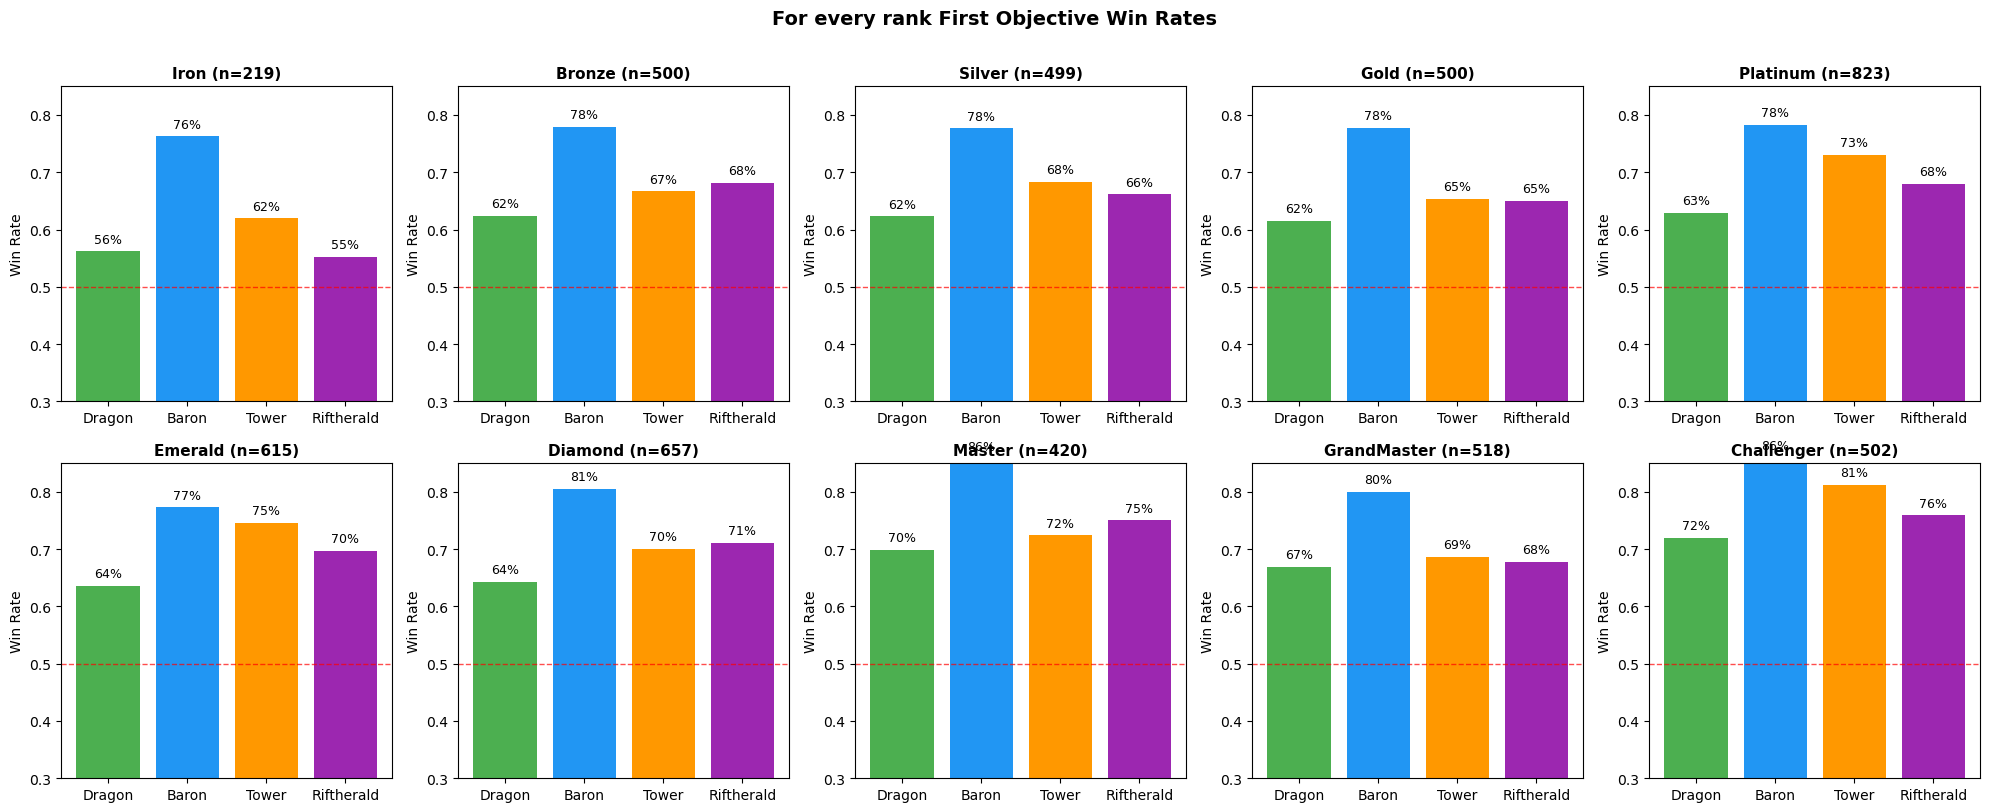


[+] winrates_by_rank.png saved

############################################################
  GENERAL SUMMARY — ALL ACCOUNTS (5253 matches)
############################################################

  WIN RATES — All Ranks
  first_dragon           Secured: 64.5%  |  Not: 40.7%  |  Fark: +23.8%
  first_baron            Secured: 80.0%  |  Not: 36.2%  |  Fark: +43.8%
  first_tower            Secured: 71.0%  |  Not: 33.6%  |  Fark: +37.4%
  first_riftherald       Secured: 69.1%  |  Not: 41.9%  |  Fark: +27.2%

  Logistic Regression Coefficients — All Ranks
         feature  coefficient
       tower_adv     5.700586
      dragon_adv     0.659099
       baron_adv     0.372857
    first_dragon     0.066670
     first_baron    -0.160032
     first_tower    -0.224741
first_riftherald    -0.277742


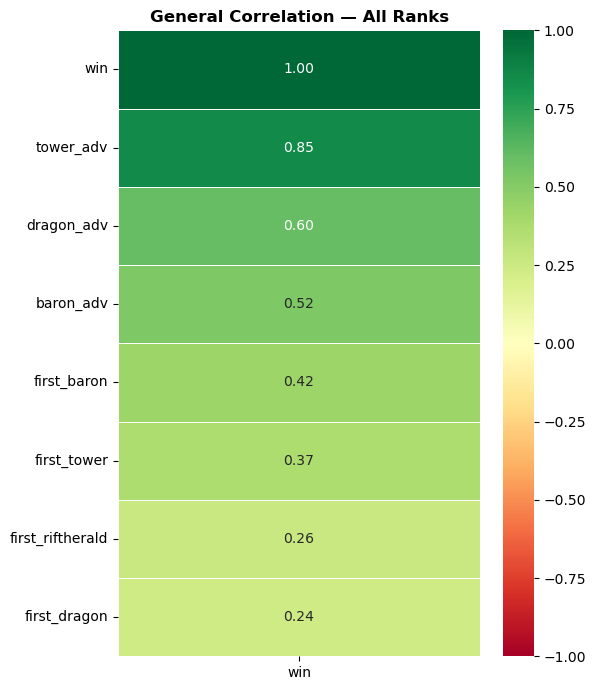

[+] correlation_full.png kaydedildi

############################################################
  MY ACCOUNTS — 759 matches
############################################################

  WIN RATES — My Accounts
  first_dragon           Secured: 70.3%  |  Not: 41.1%  |  Fark: +29.2%
  first_baron            Secured: 83.9%  |  Not: 41.4%  |  Fark: +42.5%
  first_tower            Secured: 74.2%  |  Not: 32.2%  |  Fark: +42.0%
  first_riftherald       Secured: 74.5%  |  Not: 42.6%  |  Fark: +31.9%

  Logistic Regression Coefficients — My Accounts
         feature  coefficient
       tower_adv     4.716213
      dragon_adv     0.786816
       baron_adv     0.397053
     first_baron     0.291298
    first_dragon     0.222466
     first_tower     0.001843
first_riftherald    -0.375899


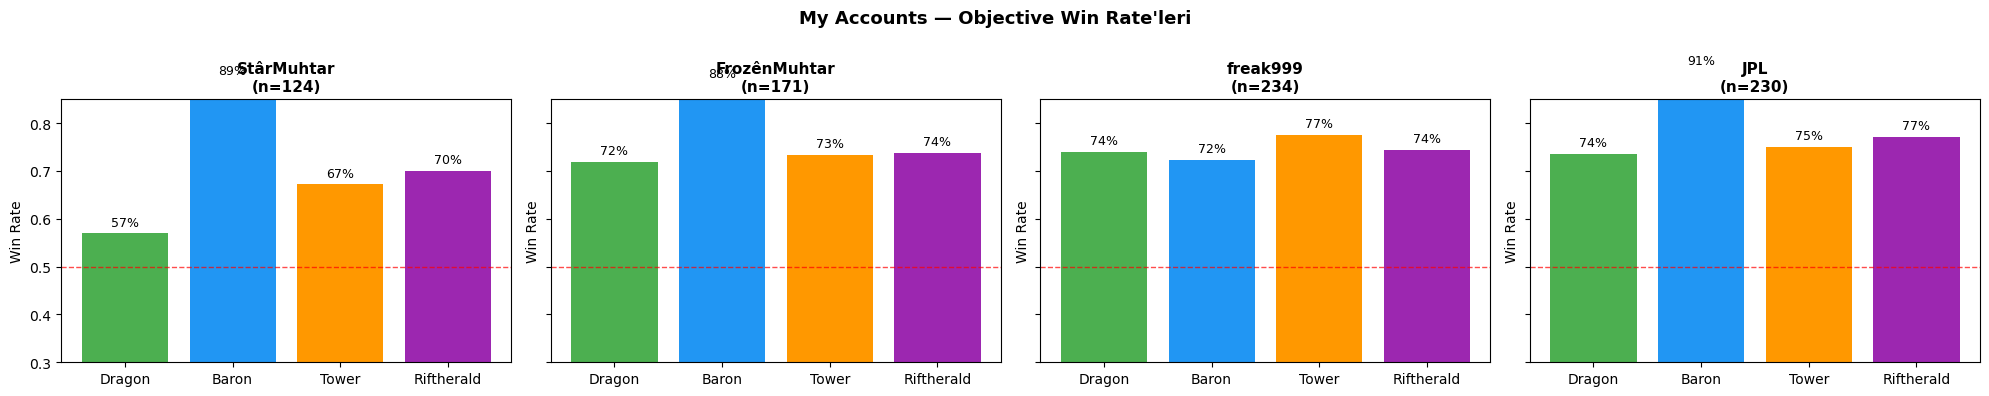

[+] my_accounts_winrates.png kaydedildi


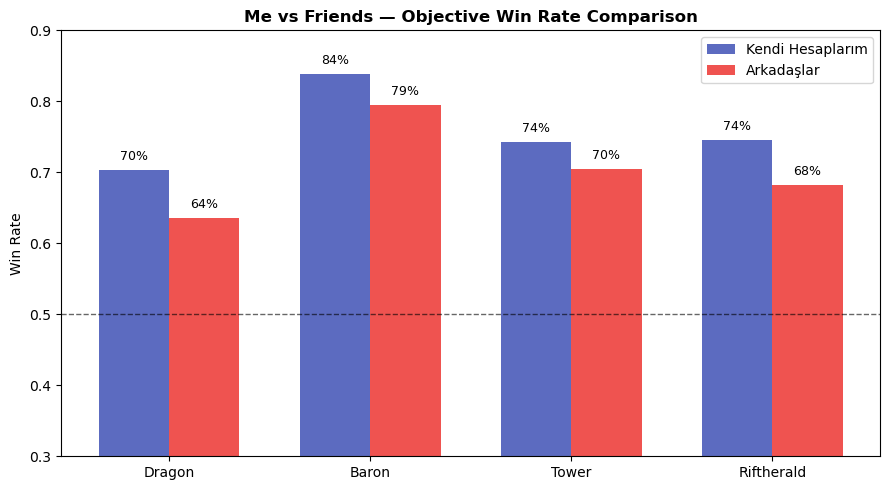

[+] me_vs_friends.png kaydedildi

############################################################
  META TIER ANALYSIS
############################################################
 meta_tier  win_rate  maç_sayısı
       1.0  0.532710         214
       2.0  0.527273         440
       3.0  0.489130          92
       4.0  0.515789          95
       5.0  0.575221         113


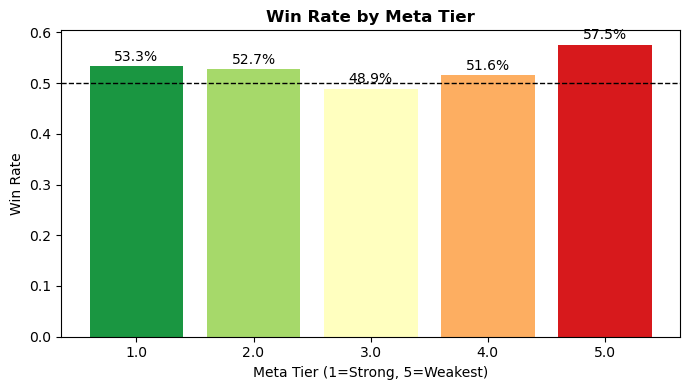

[+] meta_tier_winrate.png kaydedildi


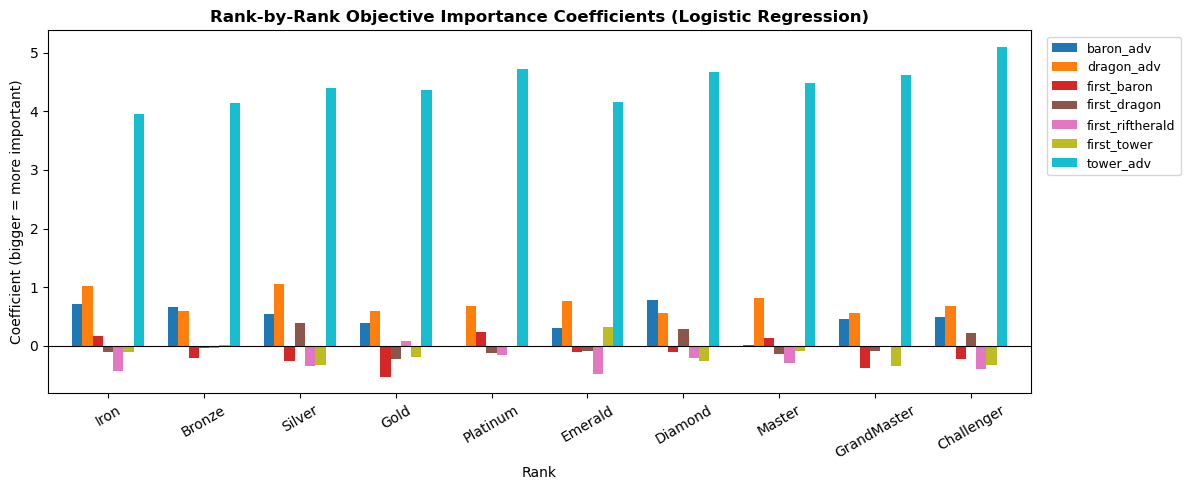

[+] coef_by_rank.png kaydedildi


In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# HESAP LİSTESİ
# ============================================================
ACCOUNTS = [
    {"name": "StârMuhtar",       "group": "mine"},
    {"name": "FrozênMuhtar",     "group": "mine"},
    {"name": "freak999",         "group": "mine"},
    {"name": "JPL",              "group": "mine"},
    {"name": "Kocanım",          "group": "friends"},
    {"name": "G0DMEN",           "group": "friends"},
    {"name": "İGOR4554",         "group": "friends"},
    {"name": "volibear444",      "group": "friends"},
    {"name": "Ricci Rocco",      "group": "friends"},
    {"name": "u88",              "group": "friends"},
    {"name": "turkish taliyah",  "group": "friends"},
    {"name": "Sihirdar Olacam",  "group": "friends"},
    {"name": "S A V A G E",      "group": "friends"},
    {"name": "KAZUMASAN2",       "group": "friends"},
    {"name": "ExpertMurderer",   "group": "friends"},
    {"name": "ÇAYCIGOSU",        "group": "friends"},
    {"name": "flame enjoyer",    "group": "friends"},
    {"name": "Xirtheasy",        "group": "friends"},
    {"name": "Ekremcantunca",    "group": "friends"},
    {"name": "herr müller",      "group": "friends"},
    {"name": "Eobard Thawne RF", "group": "friends"},
    {"name": "outmind",          "group": "friends"},
    {"name": "broski mroski",    "group": "friends"},
]

# ============================================================
# TİER LİSTELERİ
# ============================================================
tier_list_1607 = [
    {"champion": "Garen",        "role": "Top",     "tier": 1, "patch": "16.07"},
    {"champion": "Dr. Mundo",    "role": "Top",     "tier": 1, "patch": "16.07"},
    {"champion": "Briar",        "role": "Jungle",  "tier": 1, "patch": "16.07"},
    {"champion": "Kayle",        "role": "Top",     "tier": 1, "patch": "16.07"},
    {"champion": "Sona",         "role": "Support", "tier": 1, "patch": "16.07"},
    {"champion": "Malzahar",     "role": "Mid",     "tier": 1, "patch": "16.07"},
    {"champion": "Veigar",       "role": "Mid",     "tier": 1, "patch": "16.07"},
    {"champion": "Milio",        "role": "Support", "tier": 1, "patch": "16.07"},
    {"champion": "Nocturne",     "role": "Jungle",  "tier": 1, "patch": "16.07"},
    {"champion": "Soraka",       "role": "Support", "tier": 1, "patch": "16.07"},
    {"champion": "Brand",        "role": "Jungle",  "tier": 1, "patch": "16.07"},
    {"champion": "Sett",         "role": "Top",     "tier": 1, "patch": "16.07"},
    {"champion": "Nami",         "role": "Support", "tier": 1, "patch": "16.07"},
    {"champion": "Shyvana",      "role": "Jungle",  "tier": 1, "patch": "16.07"},
    {"champion": "Yorick",       "role": "Top",     "tier": 1, "patch": "16.07"},
    {"champion": "Brand",        "role": "Support", "tier": 1, "patch": "16.07"},
    {"champion": "Mordekaiser",  "role": "Top",     "tier": 1, "patch": "16.07"},
    {"champion": "Miss Fortune", "role": "ADC",     "tier": 1, "patch": "16.07"},
    {"champion": "Jinx",         "role": "ADC",     "tier": 1, "patch": "16.07"},
    {"champion": "Seraphine",    "role": "Support", "tier": 1, "patch": "16.07"},
    {"champion": "Leona",        "role": "Support", "tier": 1, "patch": "16.07"},
    {"champion": "Malphite",     "role": "Top",     "tier": 1, "patch": "16.07"},
    {"champion": "Ashe",         "role": "ADC",     "tier": 1, "patch": "16.07"},
    {"champion": "Morgana",      "role": "Support", "tier": 1, "patch": "16.07"},
    {"champion": "Thresh",       "role": "Support", "tier": 1, "patch": "16.07"},
    {"champion": "Caitlyn",      "role": "ADC",     "tier": 1, "patch": "16.07"},
    {"champion": "Lux",          "role": "Support", "tier": 2, "patch": "16.07"},
    {"champion": "Swain",        "role": "Support", "tier": 2, "patch": "16.07"},
    {"champion": "Veigar",       "role": "Support", "tier": 2, "patch": "16.07"},
    {"champion": "Rammus",       "role": "Jungle",  "tier": 2, "patch": "16.07"},
    {"champion": "Amumu",        "role": "Jungle",  "tier": 2, "patch": "16.07"},
    {"champion": "Singed",       "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Xerath",       "role": "Mid",     "tier": 2, "patch": "16.07"},
    {"champion": "Janna",        "role": "Support", "tier": 2, "patch": "16.07"},
    {"champion": "Urgot",        "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Zyra",         "role": "Support", "tier": 2, "patch": "16.07"},
    {"champion": "Maokai",       "role": "Jungle",  "tier": 2, "patch": "16.07"},
    {"champion": "Sion",         "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Diana",        "role": "Mid",     "tier": 2, "patch": "16.07"},
    {"champion": "Viktor",       "role": "Mid",     "tier": 2, "patch": "16.07"},
    {"champion": "Fizz",         "role": "Mid",     "tier": 2, "patch": "16.07"},
    {"champion": "Xin Zhao",     "role": "Jungle",  "tier": 2, "patch": "16.07"},
    {"champion": "Vex",          "role": "Mid",     "tier": 2, "patch": "16.07"},
    {"champion": "Lux",          "role": "Mid",     "tier": 2, "patch": "16.07"},
    {"champion": "Naafiri",      "role": "Jungle",  "tier": 2, "patch": "16.07"},
    {"champion": "Bard",         "role": "Support", "tier": 2, "patch": "16.07"},
    {"champion": "Shen",         "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Teemo",        "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Dr. Mundo",    "role": "Jungle",  "tier": 2, "patch": "16.07"},
    {"champion": "Xerath",       "role": "Support", "tier": 2, "patch": "16.07"},
    {"champion": "Vayne",        "role": "ADC",     "tier": 2, "patch": "16.07"},
    {"champion": "Karma",        "role": "Support", "tier": 2, "patch": "16.07"},
    {"champion": "Nasus",        "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Ahri",         "role": "Mid",     "tier": 2, "patch": "16.07"},
    {"champion": "Irelia",       "role": "Mid",     "tier": 2, "patch": "16.07"},
    {"champion": "Volibear",     "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Kayn",         "role": "Jungle",  "tier": 2, "patch": "16.07"},
    {"champion": "Master Yi",    "role": "Jungle",  "tier": 2, "patch": "16.07"},
    {"champion": "Gangplank",    "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Blitzcrank",   "role": "Support", "tier": 2, "patch": "16.07"},
    {"champion": "Tryndamere",   "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Renekton",     "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Graves",       "role": "Jungle",  "tier": 2, "patch": "16.07"},
    {"champion": "Jhin",         "role": "ADC",     "tier": 2, "patch": "16.07"},
    {"champion": "Lulu",         "role": "Support", "tier": 2, "patch": "16.07"},
    {"champion": "Nautilus",     "role": "Support", "tier": 2, "patch": "16.07"},
    {"champion": "Yasuo",        "role": "Mid",     "tier": 2, "patch": "16.07"},
    {"champion": "Yone",         "role": "Mid",     "tier": 2, "patch": "16.07"},
    {"champion": "Viego",        "role": "Jungle",  "tier": 2, "patch": "16.07"},
    {"champion": "Jax",          "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Vayne",        "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Aatrox",       "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Darius",       "role": "Top",     "tier": 2, "patch": "16.07"},
    {"champion": "Brand",        "role": "ADC",     "tier": 3, "patch": "16.07"},
    {"champion": "Sion",         "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Kog'Maw",      "role": "ADC",     "tier": 3, "patch": "16.07"},
    {"champion": "Taric",        "role": "Support", "tier": 3, "patch": "16.07"},
    {"champion": "Nasus",        "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Aurelion Sol", "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Ziggs",        "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Shen",         "role": "Jungle",  "tier": 3, "patch": "16.07"},
    {"champion": "Senna",        "role": "ADC",     "tier": 3, "patch": "16.07"},
    {"champion": "Yasuo",        "role": "ADC",     "tier": 3, "patch": "16.07"},
    {"champion": "Malphite",     "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Kled",         "role": "Top",     "tier": 3, "patch": "16.07"},
    {"champion": "Zilean",       "role": "Support", "tier": 3, "patch": "16.07"},
    {"champion": "Anivia",       "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Teemo",        "role": "Support", "tier": 3, "patch": "16.07"},
    {"champion": "Annie",        "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Lissandra",    "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Fiddlesticks", "role": "Jungle",  "tier": 3, "patch": "16.07"},
    {"champion": "Twitch",       "role": "ADC",     "tier": 3, "patch": "16.07"},
    {"champion": "Naafiri",      "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Volibear",     "role": "Jungle",  "tier": 3, "patch": "16.07"},
    {"champion": "Vex",          "role": "Support", "tier": 3, "patch": "16.07"},
    {"champion": "Jarvan IV",    "role": "Jungle",  "tier": 3, "patch": "16.07"},
    {"champion": "Heimerdinger", "role": "Top",     "tier": 3, "patch": "16.07"},
    {"champion": "Jax",          "role": "Jungle",  "tier": 3, "patch": "16.07"},
    {"champion": "Hwei",         "role": "Support", "tier": 3, "patch": "16.07"},
    {"champion": "Irelia",       "role": "Top",     "tier": 3, "patch": "16.07"},
    {"champion": "Olaf",         "role": "Top",     "tier": 3, "patch": "16.07"},
    {"champion": "Twisted Fate", "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Warwick",      "role": "Jungle",  "tier": 3, "patch": "16.07"},
    {"champion": "Tahm Kench",   "role": "Top",     "tier": 3, "patch": "16.07"},
    {"champion": "Pantheon",     "role": "Top",     "tier": 3, "patch": "16.07"},
    {"champion": "Vi",           "role": "Jungle",  "tier": 3, "patch": "16.07"},
    {"champion": "Katarina",     "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Cho'Gath",     "role": "Top",     "tier": 3, "patch": "16.07"},
    {"champion": "Rakan",        "role": "Support", "tier": 3, "patch": "16.07"},
    {"champion": "Trundle",      "role": "Top",     "tier": 3, "patch": "16.07"},
    {"champion": "Akali",        "role": "Top",     "tier": 3, "patch": "16.07"},
    {"champion": "Lillia",       "role": "Jungle",  "tier": 3, "patch": "16.07"},
    {"champion": "Yuumi",        "role": "Support", "tier": 3, "patch": "16.07"},
    {"champion": "Alistar",      "role": "Support", "tier": 3, "patch": "16.07"},
    {"champion": "Akali",        "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Ekko",         "role": "Jungle",  "tier": 3, "patch": "16.07"},
    {"champion": "Lee Sin",      "role": "Jungle",  "tier": 3, "patch": "16.07"},
    {"champion": "Kai'Sa",       "role": "ADC",     "tier": 3, "patch": "16.07"},
    {"champion": "Sylas",        "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Zed",          "role": "Mid",     "tier": 3, "patch": "16.07"},
    {"champion": "Pyke",         "role": "Support", "tier": 3, "patch": "16.07"},
    {"champion": "Annie",        "role": "Support", "tier": 4, "patch": "16.07"},
    {"champion": "Anivia",       "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Morgana",      "role": "Mid",     "tier": 4, "patch": "16.07"},
    {"champion": "Teemo",        "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Malphite",     "role": "Support", "tier": 4, "patch": "16.07"},
    {"champion": "Hwei",         "role": "Mid",     "tier": 4, "patch": "16.07"},
    {"champion": "Evelynn",      "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Sejuani",      "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Renata Glasc", "role": "Support", "tier": 4, "patch": "16.07"},
    {"champion": "Elise",        "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Warwick",      "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Rek'Sai",      "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Hwei",         "role": "ADC",     "tier": 4, "patch": "16.07"},
    {"champion": "Trundle",      "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Nidalee",      "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Swain",        "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Bel'Veth",     "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Nunu",         "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Nilah",        "role": "ADC",     "tier": 4, "patch": "16.07"},
    {"champion": "Lillia",       "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Ekko",         "role": "Mid",     "tier": 4, "patch": "16.07"},
    {"champion": "Poppy",        "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Diana",        "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Yorick",       "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Alistar",      "role": "Mid",     "tier": 4, "patch": "16.07"},
    {"champion": "Zac",          "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Shen",         "role": "Support", "tier": 4, "patch": "16.07"},
    {"champion": "Kassadin",     "role": "Mid",     "tier": 4, "patch": "16.07"},
    {"champion": "Varus",        "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Quinn",        "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Vladimir",     "role": "Mid",     "tier": 4, "patch": "16.07"},
    {"champion": "Shaco",        "role": "Support", "tier": 4, "patch": "16.07"},
    {"champion": "Vladimir",     "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Aphelios",     "role": "ADC",     "tier": 4, "patch": "16.07"},
    {"champion": "Sylas",        "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Camille",      "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Aurora",       "role": "Mid",     "tier": 4, "patch": "16.07"},
    {"champion": "Amumu",        "role": "Support", "tier": 4, "patch": "16.07"},
    {"champion": "Zoe",          "role": "Mid",     "tier": 4, "patch": "16.07"},
    {"champion": "Kennen",       "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Draven",       "role": "ADC",     "tier": 4, "patch": "16.07"},
    {"champion": "Tristana",     "role": "ADC",     "tier": 4, "patch": "16.07"},
    {"champion": "Sylas",        "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Shaco",        "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Rumble",       "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Malphite",     "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Riven",        "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Neeko",        "role": "Support", "tier": 4, "patch": "16.07"},
    {"champion": "Gwen",         "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Kha'Zix",      "role": "Jungle",  "tier": 4, "patch": "16.07"},
    {"champion": "Lucian",       "role": "ADC",     "tier": 4, "patch": "16.07"},
    {"champion": "Twitch",       "role": "Support", "tier": 4, "patch": "16.07"},
    {"champion": "Jayce",        "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Orianna",      "role": "Mid",     "tier": 4, "patch": "16.07"},
    {"champion": "Yone",         "role": "Top",     "tier": 4, "patch": "16.07"},
    {"champion": "Irelia",       "role": "ADC",     "tier": 4, "patch": "16.07"},
    {"champion": "Cho'Gath",     "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "Heimerdinger", "role": "Mid",     "tier": 5, "patch": "16.07"},
    {"champion": "Tryndamere",   "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "Cho'Gath",     "role": "Mid",     "tier": 5, "patch": "16.07"},
    {"champion": "Aatrox",       "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "Ivern",        "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "Nidalee",      "role": "Top",     "tier": 5, "patch": "16.07"},
    {"champion": "Aurora",       "role": "Top",     "tier": 5, "patch": "16.07"},
    {"champion": "Zac",          "role": "Top",     "tier": 5, "patch": "16.07"},
    {"champion": "Jayce",        "role": "Mid",     "tier": 5, "patch": "16.07"},
    {"champion": "Gwen",         "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "LeBlanc",      "role": "Support", "tier": 5, "patch": "16.07"},
    {"champion": "Lillia",       "role": "Support", "tier": 5, "patch": "16.07"},
    {"champion": "Karthus",      "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "Ryze",         "role": "Top",     "tier": 5, "patch": "16.07"},
    {"champion": "Cassiopeia",   "role": "Mid",     "tier": 5, "patch": "16.07"},
    {"champion": "Pantheon",     "role": "Support", "tier": 5, "patch": "16.07"},
    {"champion": "Zoe",          "role": "Support", "tier": 5, "patch": "16.07"},
    {"champion": "Skarner",      "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "Kindred",      "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "Hecarim",      "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "Veigar",       "role": "ADC",     "tier": 5, "patch": "16.07"},
    {"champion": "Talon",        "role": "Mid",     "tier": 5, "patch": "16.07"},
    {"champion": "Corki",        "role": "ADC",     "tier": 5, "patch": "16.07"},
    {"champion": "Anivia",       "role": "Support", "tier": 5, "patch": "16.07"},
    {"champion": "Gragas",       "role": "Top",     "tier": 5, "patch": "16.07"},
    {"champion": "Qiyana",       "role": "Mid",     "tier": 5, "patch": "16.07"},
    {"champion": "Talon",        "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "Brand",        "role": "Mid",     "tier": 5, "patch": "16.07"},
    {"champion": "Zed",          "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "Kalista",      "role": "ADC",     "tier": 5, "patch": "16.07"},
    {"champion": "Master Yi",    "role": "Top",     "tier": 5, "patch": "16.07"},
    {"champion": "Ryze",         "role": "Mid",     "tier": 5, "patch": "16.07"},
    {"champion": "Varus",        "role": "ADC",     "tier": 5, "patch": "16.07"},
    {"champion": "Nidalee",      "role": "Support", "tier": 5, "patch": "16.07"},
    {"champion": "Taliyah",      "role": "Mid",     "tier": 5, "patch": "16.07"},
    {"champion": "Rengar",       "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "K'Sante",      "role": "Top",     "tier": 5, "patch": "16.07"},
    {"champion": "Qiyana",       "role": "Jungle",  "tier": 5, "patch": "16.07"},
    {"champion": "Azir",         "role": "Mid",     "tier": 5, "patch": "16.07"},
    {"champion": "Ashe",         "role": "Support", "tier": 5, "patch": "16.07"},
    {"champion": "Shyvana",      "role": "Top",     "tier": 5, "patch": "16.07"},
]

tier_list_1606 = [
    {"champion": "Amumu",        "role": "Jungle",  "tier": 1, "patch": "16.06"},
    {"champion": "Jinx",         "role": "ADC",     "tier": 1, "patch": "16.06"},
    {"champion": "Dr. Mundo",    "role": "Top",     "tier": 1, "patch": "16.06"},
    {"champion": "Amumu",        "role": "Support", "tier": 1, "patch": "16.06"},
    {"champion": "Sona",         "role": "Support", "tier": 1, "patch": "16.06"},
    {"champion": "Garen",        "role": "Top",     "tier": 1, "patch": "16.06"},
    {"champion": "Veigar",       "role": "Mid",     "tier": 1, "patch": "16.06"},
    {"champion": "Sett",         "role": "Top",     "tier": 1, "patch": "16.06"},
    {"champion": "Nami",         "role": "Support", "tier": 1, "patch": "16.06"},
    {"champion": "Milio",        "role": "Support", "tier": 1, "patch": "16.06"},
    {"champion": "Malzahar",     "role": "Mid",     "tier": 1, "patch": "16.06"},
    {"champion": "Lux",          "role": "Support", "tier": 1, "patch": "16.06"},
    {"champion": "Leona",        "role": "Support", "tier": 1, "patch": "16.06"},
    {"champion": "Shyvana",      "role": "Jungle",  "tier": 1, "patch": "16.06"},
    {"champion": "Yorick",       "role": "Top",     "tier": 1, "patch": "16.06"},
    {"champion": "Miss Fortune",  "role": "ADC",    "tier": 1, "patch": "16.06"},
    {"champion": "Soraka",       "role": "Support", "tier": 1, "patch": "16.06"},
    {"champion": "Mordekaiser",  "role": "Top",     "tier": 1, "patch": "16.06"},
    {"champion": "Malphite",     "role": "Top",     "tier": 1, "patch": "16.06"},
    {"champion": "Ashe",         "role": "ADC",     "tier": 1, "patch": "16.06"},
    {"champion": "Seraphine",    "role": "Support", "tier": 1, "patch": "16.06"},
    {"champion": "Morgana",      "role": "Support", "tier": 1, "patch": "16.06"},
    {"champion": "Thresh",       "role": "Support", "tier": 1, "patch": "16.06"},
    {"champion": "Swain",        "role": "Support", "tier": 1, "patch": "16.06"},
    {"champion": "Shyvana",      "role": "Top",     "tier": 1, "patch": "16.06"},
    {"champion": "Caitlyn",      "role": "ADC",     "tier": 2, "patch": "16.06"},
    {"champion": "Lux",          "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Veigar",       "role": "Support", "tier": 2, "patch": "16.06"},
    {"champion": "Singed",       "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Sion",         "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Kayle",        "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Mordekaiser",  "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Rammus",       "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Sion",         "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Xerath",       "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Janna",        "role": "Support", "tier": 2, "patch": "16.06"},
    {"champion": "Janna",        "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Zyra",         "role": "Support", "tier": 2, "patch": "16.06"},
    {"champion": "Brand",        "role": "Support", "tier": 2, "patch": "16.06"},
    {"champion": "Maokai",       "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Urgot",        "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Diana",        "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Volibear",     "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Xerath",       "role": "Support", "tier": 2, "patch": "16.06"},
    {"champion": "Fizz",         "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Naafiri",      "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Shen",         "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Teemo",        "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Viktor",       "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Braum",        "role": "Support", "tier": 2, "patch": "16.06"},
    {"champion": "Samira",       "role": "ADC",     "tier": 2, "patch": "16.06"},
    {"champion": "Fiddlesticks", "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Vex",          "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Lux",          "role": "ADC",     "tier": 2, "patch": "16.06"},
    {"champion": "Xin Zhao",     "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Vayne",        "role": "ADC",     "tier": 2, "patch": "16.06"},
    {"champion": "Dr. Mundo",    "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Naafiri",      "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Lulu",         "role": "Support", "tier": 2, "patch": "16.06"},
    {"champion": "Xerath",       "role": "ADC",     "tier": 2, "patch": "16.06"},
    {"champion": "Annie",        "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Hwei",         "role": "Support", "tier": 2, "patch": "16.06"},
    {"champion": "Karma",        "role": "Support", "tier": 2, "patch": "16.06"},
    {"champion": "Ziggs",        "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Jarvan IV",    "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Olaf",         "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Volibear",     "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Yone",         "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Tryndamere",   "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Jhin",         "role": "ADC",     "tier": 2, "patch": "16.06"},
    {"champion": "Warwick",      "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Kayn",         "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Vi",           "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Blitzcrank",   "role": "Support", "tier": 2, "patch": "16.06"},
    {"champion": "Bel'Veth",     "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Ivern",        "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Nautilus",     "role": "Support", "tier": 2, "patch": "16.06"},
    {"champion": "Zac",          "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Yasuo",        "role": "Mid",     "tier": 2, "patch": "16.06"},
    {"champion": "Jax",          "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Viego",        "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Karma",        "role": "Top",     "tier": 2, "patch": "16.06"},
    {"champion": "Karthus",      "role": "Jungle",  "tier": 2, "patch": "16.06"},
    {"champion": "Senna",        "role": "ADC",     "tier": 3, "patch": "16.06"},
    {"champion": "Nunu",         "role": "Jungle",  "tier": 3, "patch": "16.06"},
    {"champion": "Milio",        "role": "Mid",     "tier": 3, "patch": "16.06"},
    {"champion": "Lucian",       "role": "ADC",     "tier": 3, "patch": "16.06"},
    {"champion": "Nilah",        "role": "ADC",     "tier": 3, "patch": "16.06"},
    {"champion": "Kog'Maw",      "role": "ADC",     "tier": 3, "patch": "16.06"},
    {"champion": "Anivia",       "role": "Mid",     "tier": 3, "patch": "16.06"},
    {"champion": "Swain",        "role": "Top",     "tier": 3, "patch": "16.06"},
    {"champion": "Taric",        "role": "Support", "tier": 3, "patch": "16.06"},
    {"champion": "Nasus",        "role": "Mid",     "tier": 3, "patch": "16.06"},
    {"champion": "Darius",       "role": "Top",     "tier": 3, "patch": "16.06"},
    {"champion": "Kled",         "role": "Top",     "tier": 3, "patch": "16.06"},
    {"champion": "Zilean",       "role": "Support", "tier": 3, "patch": "16.06"},
    {"champion": "Lissandra",    "role": "Mid",     "tier": 3, "patch": "16.06"},
    {"champion": "Heimerdinger", "role": "Mid",     "tier": 3, "patch": "16.06"},
    {"champion": "Katarina",     "role": "Mid",     "tier": 3, "patch": "16.06"},
    {"champion": "Zac",          "role": "Top",     "tier": 3, "patch": "16.06"},
    {"champion": "Renekton",     "role": "Top",     "tier": 3, "patch": "16.06"},
    {"champion": "Urgot",        "role": "Jungle",  "tier": 3, "patch": "16.06"},
    {"champion": "Irelia",       "role": "Mid",     "tier": 3, "patch": "16.06"},
    {"champion": "Hwei",         "role": "Mid",     "tier": 3, "patch": "16.06"},
    {"champion": "Kai'Sa",       "role": "ADC",     "tier": 3, "patch": "16.06"},
    {"champion": "Ekko",         "role": "Jungle",  "tier": 3, "patch": "16.06"},
    {"champion": "Draven",       "role": "ADC",     "tier": 3, "patch": "16.06"},
    {"champion": "Tristana",     "role": "ADC",     "tier": 3, "patch": "16.06"},
    {"champion": "Lee Sin",      "role": "Jungle",  "tier": 3, "patch": "16.06"},
    {"champion": "Sylas",        "role": "Mid",     "tier": 3, "patch": "16.06"},
    {"champion": "Taliyah",      "role": "Mid",     "tier": 3, "patch": "16.06"},
    {"champion": "Zed",          "role": "Mid",     "tier": 3, "patch": "16.06"},
    {"champion": "Gangplank",    "role": "Top",     "tier": 4, "patch": "16.06"},
    {"champion": "Tahm Kench",   "role": "Top",     "tier": 4, "patch": "16.06"},
    {"champion": "Ryze",         "role": "Mid",     "tier": 4, "patch": "16.06"},
    {"champion": "Vladimir",     "role": "Mid",     "tier": 4, "patch": "16.06"},
    {"champion": "Akali",        "role": "Mid",     "tier": 4, "patch": "16.06"},
    {"champion": "Twisted Fate", "role": "Mid",     "tier": 4, "patch": "16.06"},
    {"champion": "Rengar",       "role": "Jungle",  "tier": 4, "patch": "16.06"},
    {"champion": "Azir",         "role": "Mid",     "tier": 4, "patch": "16.06"},
    {"champion": "K'Sante",      "role": "Top",     "tier": 4, "patch": "16.06"},
    {"champion": "Qiyana",       "role": "Mid",     "tier": 4, "patch": "16.06"},
    {"champion": "LeBlanc",      "role": "Support", "tier": 5, "patch": "16.06"},
    {"champion": "Zoe",          "role": "Support", "tier": 5, "patch": "16.06"},
    {"champion": "Ryze",         "role": "Top",     "tier": 5, "patch": "16.06"},
    {"champion": "Skarner",      "role": "Jungle",  "tier": 5, "patch": "16.06"},
    {"champion": "Veigar",       "role": "ADC",     "tier": 5, "patch": "16.06"},
    {"champion": "Cassiopeia",   "role": "Mid",     "tier": 5, "patch": "16.06"},
    {"champion": "Corki",        "role": "ADC",     "tier": 5, "patch": "16.06"},
    {"champion": "Anivia",       "role": "Support", "tier": 5, "patch": "16.06"},
    {"champion": "Gragas",       "role": "Top",     "tier": 5, "patch": "16.06"},
    {"champion": "Qiyana",       "role": "Mid",     "tier": 5, "patch": "16.06"},
    {"champion": "Master Yi",    "role": "Top",     "tier": 5, "patch": "16.06"},
    {"champion": "Malphite",     "role": "Support", "tier": 5, "patch": "16.06"},
    {"champion": "Nidalee",      "role": "Jungle",  "tier": 5, "patch": "16.06"},
    {"champion": "Brand",        "role": "Mid",     "tier": 5, "patch": "16.06"},
    {"champion": "Orianna",      "role": "Mid",     "tier": 5, "patch": "16.06"},
    {"champion": "Zed",          "role": "Jungle",  "tier": 5, "patch": "16.06"},
    {"champion": "Varus",        "role": "ADC",     "tier": 5, "patch": "16.06"},
    {"champion": "Ryze",         "role": "Mid",     "tier": 5, "patch": "16.06"},
    {"champion": "Taliyah",      "role": "Mid",     "tier": 5, "patch": "16.06"},
    {"champion": "Kalista",      "role": "ADC",     "tier": 5, "patch": "16.06"},
    {"champion": "Ashe",         "role": "Support", "tier": 5, "patch": "16.06"},
    {"champion": "Rengar",       "role": "Jungle",  "tier": 5, "patch": "16.06"},
    {"champion": "Qiyana",       "role": "Jungle",  "tier": 5, "patch": "16.06"},
    {"champion": "K'Sante",      "role": "Top",     "tier": 5, "patch": "16.06"},
    {"champion": "Azir",         "role": "Mid",     "tier": 5, "patch": "16.06"},
    {"champion": "Shyvana",      "role": "Top",     "tier": 5, "patch": "16.06"},
]

# ============================================================
# 1. VERİ OKUMA
# ============================================================
df = pd.read_csv("lol_dataset.csv")

# ============================================================
# 2. GROUP KOLONU — ACCOUNTS listesinden map'le
# ============================================================
group_map = {acc['name']: acc['group'] for acc in ACCOUNTS}
df['group'] = df['player'].map(group_map)

missing_group = df[df['group'].isna()]['player'].unique()
if len(missing_group) > 0:
    print(f"⚠️  unmatched groups for {len(missing_group)} players: {missing_group}")
else:
    print(f"✅ group column OK — mine: {(df['group']=='mine').sum()}, friends: {(df['group']=='friends').sum()} matches")

# ============================================================
# 3. TİER DF BİRLEŞTİR + MERGE
# ============================================================
tier_df = pd.concat([
    pd.DataFrame(tier_list_1607),
    pd.DataFrame(tier_list_1606)
], ignore_index=True)

role_map = {
    "TOP":     "Top",
    "JUNGLE":  "Jungle",
    "MIDDLE":  "Mid",
    "BOTTOM":  "ADC",
    "UTILITY": "Support"
}
df['role_mapped'] = df['role'].map(role_map)

def normalize_patch(v):
    try:
        parts = str(v).split('.')
        return f"{parts[0]}.{parts[1].zfill(2)}"
    except:
        return None

df['patch'] = df['patch'].apply(normalize_patch)

df = df.merge(
    tier_df[['champion', 'role', 'tier', 'patch']],
    left_on=['champion', 'role_mapped', 'patch'],
    right_on=['champion', 'role', 'patch'],
    how='left'
).rename(columns={'tier': 'meta_tier'})

missing_tier = df[df['meta_tier'].isna()][['champion', 'role_mapped', 'patch']].drop_duplicates()
print(f"\nUnmatched {len(missing_tier)} tier combinations")
print(f"Total: {len(df)} | Matched: {df['meta_tier'].notna().sum()} | Rate: {df['meta_tier'].notna().mean():.1%}")

# ============================================================
# 4. SABİTLER VE YARDIMCI FONKSİYONLAR
# ============================================================
RANK_ORDER = ['Iron', 'Bronze', 'Silver', 'Gold', 'Platinum', 'Emerald',
              'Diamond', 'Master', 'GrandMaster', 'Challenger']

obj_cols     = ['first_dragon', 'first_baron', 'first_tower', 'first_riftherald']
adv_cols     = ['dragon_adv', 'baron_adv', 'tower_adv']
all_features = obj_cols + adv_cols

def print_winrates(data, label=""):
    print(f"\n{'='*50}")
    print(f"  WIN RATES — {label}")
    print(f"{'='*50}")
    for col in obj_cols:
        if col not in data.columns:
            continue
        wr = data.groupby(col)['win'].mean()
        secured     = wr.get(1, float('nan'))
        not_secured = wr.get(0, float('nan'))
        diff = secured - not_secured
        print(f"  {col:<22} Secured: {secured:.1%}  |  Not: {not_secured:.1%}  |  Fark: +{diff:.1%}")

def run_logistic(data, label=""):
    available = [f for f in all_features if f in data.columns]
    if len(data) < 30:
        print(f"\n[{label}] Insufficient data ({len(data)} rows), logistic regression skipped.")
        return None
    X = data[available]
    y = data['win']
    X_scaled = StandardScaler().fit_transform(X)
    model = LogisticRegression(max_iter=500)
    model.fit(X_scaled, y)
    coef_df = pd.DataFrame({'feature': available, 'coefficient': model.coef_[0]})
    coef_df = coef_df.sort_values('coefficient', ascending=False)
    print(f"\n  Logistic Regression Coefficients — {label}")
    print(coef_df.to_string(index=False))
    return coef_df

def plot_winrate_bar(data, label, ax):
    rates = []
    for col in obj_cols:
        wr = data.groupby(col)['win'].mean()
        rates.append({
            'objective': col.replace('first_', '').capitalize(),
            'win_rate':  wr.get(1, 0)
        })
    rates_df = pd.DataFrame(rates)
    bars = ax.bar(rates_df['objective'], rates_df['win_rate'],
                  color=['#4CAF50', '#2196F3', '#FF9800', '#9C27B0'])
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Win Rate')
    ax.set_ylim(0.3, 0.85)
    for bar, rate in zip(bars, rates_df['win_rate']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{rate:.0%}', ha='center', va='bottom', fontsize=9)

# ============================================================
# 5. HER RANK İÇİN ANALİZ
# ============================================================
ranks_in_data = [r for r in RANK_ORDER if r in df['rank'].unique()]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
rank_coefs = {}

for i, rank in enumerate(ranks_in_data):
    group = df[df['rank'] == rank].copy()
    n = len(group)
    print(f"\n{'#'*60}")
    print(f"  RANK: {rank.upper()}  ({n} maç)")
    print(f"{'#'*60}")
    print_winrates(group, rank)
    print(f"\n  Korelasyonlar (win ile):")
    corr = group[all_features + ['win']].corr()['win'].drop('win').sort_values(ascending=False)
    print(corr.to_string())
    coef = run_logistic(group, rank)
    if coef is not None:
        rank_coefs[rank] = coef.set_index('feature')['coefficient']
    if i < len(axes):
        plot_winrate_bar(group, f"{rank} (n={n})", axes[i])

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("For every rank First Objective Win Rates", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("winrates_by_rank.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n[+] winrates_by_rank.png saved")

# ============================================================
# 6. GENERAL SUMMARY
# ============================================================
print(f"\n{'#'*60}")
print(f"  GENERAL SUMMARY — ALL ACCOUNTS ({len(df)} matches)")
print(f"{'#'*60}")
print_winrates(df, "All Ranks")
run_logistic(df, "All Ranks")

fig, ax = plt.subplots(figsize=(6, 7))
corr_full = df[all_features + ['win']].corr()
sns.heatmap(corr_full[['win']].sort_values('win', ascending=False),
            annot=True, fmt='.2f', cmap='RdYlGn', ax=ax,
            vmin=-1, vmax=1, linewidths=0.5)
ax.set_title("General Correlation — All Ranks", fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_full.png", dpi=150)
plt.show()
print("[+] correlation_full.png kaydedildi")

# ============================================================
# 7. MY ACCOUNTS ANALYSIS
# ============================================================
if 'group' not in df.columns or df['group'].isna().all():
    print("\n⚠️  'group' column not found — personal analysis skipped.")
else:
    my_accounts     = df[df['group'] == 'mine']
    friend_accounts = df[df['group'] == 'friends']

    print(f"\n{'#'*60}")
    print(f"  MY ACCOUNTS — {len(my_accounts)} matches")
    print(f"{'#'*60}")
    print_winrates(my_accounts, "My Accounts")
    run_logistic(my_accounts, "My Accounts")

    # Her hesap için ayrı grafik
    my_names = my_accounts['player'].unique()
    if len(my_names) > 0:
        fig, axes = plt.subplots(1, max(len(my_names), 1), figsize=(5 * len(my_names), 4), sharey=True)
        if len(my_names) == 1:
            axes = [axes]
        for i, name in enumerate(my_names):
            acc_data = my_accounts[my_accounts['player'] == name]
            plot_winrate_bar(acc_data, f"{name}\n(n={len(acc_data)})", axes[i])
        plt.suptitle("My Accounts — Objective Win Rate'leri", fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig("my_accounts_winrates.png", dpi=150, bbox_inches='tight')
        plt.show()
        print("[+] my_accounts_winrates.png kaydedildi")

    # Ben vs Arkadaşlar karşılaştırma
    fig, ax = plt.subplots(figsize=(9, 5))
    x = range(len(obj_cols))
    width = 0.35
    labels = [c.replace('first_', '').capitalize() for c in obj_cols]

    my_rates     = [my_accounts.groupby(c)['win'].mean().get(1, 0) for c in obj_cols]
    friend_rates = [friend_accounts.groupby(c)['win'].mean().get(1, 0) for c in obj_cols]

    bars1 = ax.bar([i - width/2 for i in x], my_rates,     width, label='Kendi Hesaplarım', color='#5C6BC0')
    bars2 = ax.bar([i + width/2 for i in x], friend_rates, width, label='Arkadaşlar',        color='#EF5350')

    ax.axhline(0.5, color='black', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_ylabel('Win Rate')
    ax.set_ylim(0.3, 0.9)
    ax.set_title("Me vs Friends — Objective Win Rate Comparison", fontweight='bold')
    ax.legend()

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig("me_vs_friends.png", dpi=150)
    plt.show()
    print("[+] me_vs_friends.png kaydedildi")

# ============================================================
# 8. META TIER ANALYSIS
# ============================================================
if 'meta_tier' in df.columns and df['meta_tier'].notna().sum() > 50:
    print(f"\n{'#'*60}")
    print(f"  META TIER ANALYSIS")
    print(f"{'#'*60}")
    tier_wr = df.groupby('meta_tier')['win'].agg(['mean', 'count']).reset_index()
    tier_wr.columns = ['meta_tier', 'win_rate', 'maç_sayısı']
    tier_wr = tier_wr.sort_values('meta_tier')
    print(tier_wr.to_string(index=False))

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(tier_wr['meta_tier'].astype(str), tier_wr['win_rate'],
           color=['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c'])
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
    ax.set_xlabel("Meta Tier (1=Strong, 5=Weakest)")
    ax.set_ylabel("Win Rate")
    ax.set_title("Win Rate by Meta Tier", fontweight='bold')
    for bar, wr in zip(ax.patches, tier_wr['win_rate']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{wr:.1%}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.savefig("meta_tier_winrate.png", dpi=150)
    plt.show()
    print("[+] meta_tier_winrate.png kaydedildi")

# ============================================================
# 9. RANK KARŞILAŞTIRMA GRAFİĞİ
# ============================================================
if rank_coefs:
    coef_compare = pd.DataFrame(rank_coefs).T
    coef_compare = coef_compare.reindex([r for r in RANK_ORDER if r in coef_compare.index])

    fig, ax = plt.subplots(figsize=(12, 5))
    coef_compare.plot(kind='bar', ax=ax, colormap='tab10', width=0.75)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title("Rank-by-Rank Objective Importance Coefficients (Logistic Regression)", fontweight='bold')
    ax.set_xlabel("Rank")
    ax.set_ylabel("Coefficient (bigger = more important)")
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("coef_by_rank.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("[+] coef_by_rank.png kaydedildi")